In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# better visuals
sns.set_style("whitegrid")
from google.colab import files
uploaded = files.upload()

Saving train.csv to train (2).csv


In [ ]:
df = pd.read_csv("train.csv")  # change name
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


### 📌 Problem Statement
The objective of this analysis is to evaluate sales performance, customer segmentation, product trends, and delivery efficiency for an e-commerce dataset. The goal is to derive actionable business insights that can support decision-making.

In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


df = df.dropna()  # simple method for now

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')

In [ ]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

### 🧹 Data Cleaning & Preparation
- Converted 'Order Date' and 'Ship Date' into datetime format
- Handled date format inconsistencies using day-first parsing
- Removed missing/null values to ensure clean analysis
- Created new features such as 'Year' and 'Month' for trend analysis
- Engineered 'Shipping Days' feature to analyze delivery performance

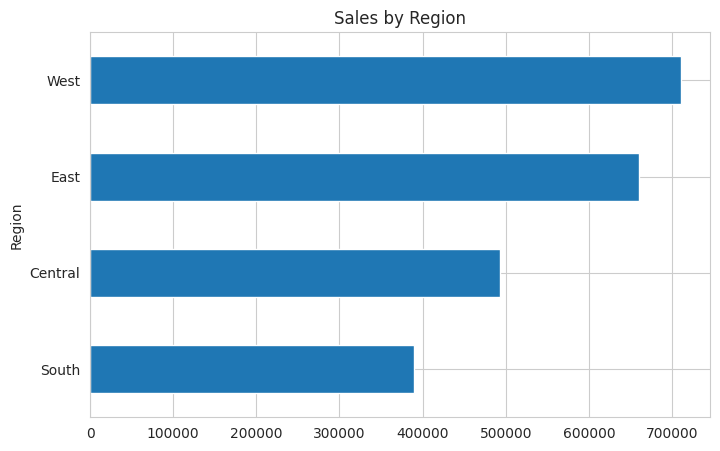

In [ ]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values()

region_sales.plot(kind='barh', figsize=(8,5))
plt.title("Sales by Region")
plt.show()

### 🌍 Sales by Region - Insight
The West region contributes the highest share of total sales, indicating strong market performance. Other regions show comparatively lower contribution, suggesting potential areas for expansion or targeted marketing.

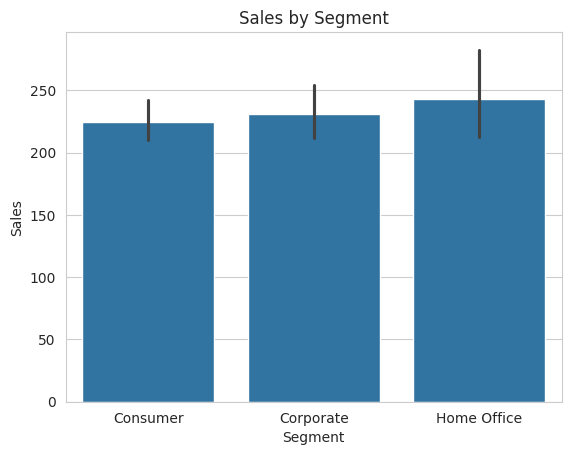

In [ ]:
sns.barplot(x='Segment', y='Sales', data=df)
plt.title("Sales by Segment")
plt.show()

### 👥 Sales by Segment - Insight
The Consumer segment dominates sales, contributing approximately half of the total revenue. This indicates that individual customers are the primary revenue drivers compared to Corporate and Home Office segments.

sns.barplot(x='Category', y='Sales', data=df)
plt.title("Sales by Category")
plt.show()

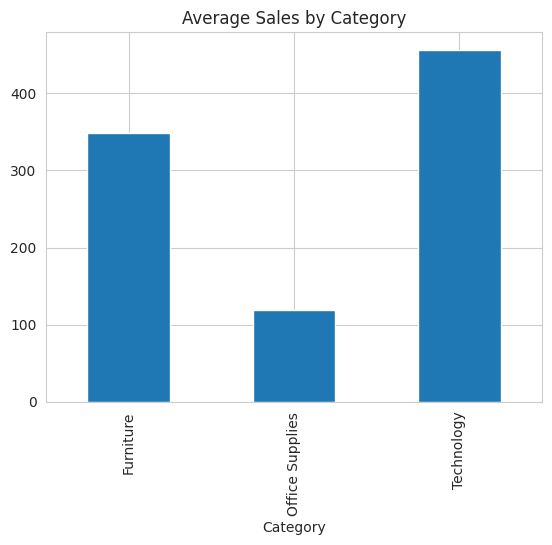

In [23]:
df.groupby('Category')['Sales'].mean().plot(kind='bar')
plt.title("Average Sales by Category")
plt.show()

### 📦 Category Analysis - Insight
The Technology category generates the highest revenue among all categories, followed by Furniture and Office Supplies. This suggests a strong demand for technology-related products.

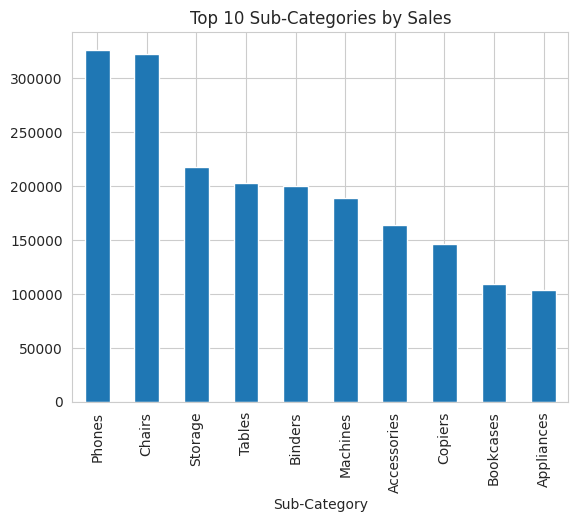

In [26]:
top_subcat = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

top_subcat.head(10).plot(kind='bar')
plt.title("Top 10 Sub-Categories by Sales")
plt.show()

### 🏷️ Sub-Category Analysis - Insight
A few sub-categories such as Phones, Chairs, and Storage contribute significantly to overall sales. This indicates that revenue is concentrated in a limited number of product segments.

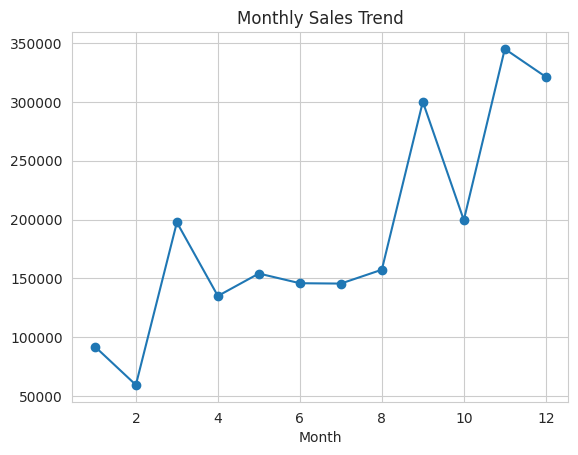

In [ ]:
monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.show()

### 📈 Sales Trend Analysis - Insight
Sales show a consistent upward trend over time with noticeable spikes during the September to December period. This indicates seasonality, likely driven by festive demand or year-end purchasing behavior.

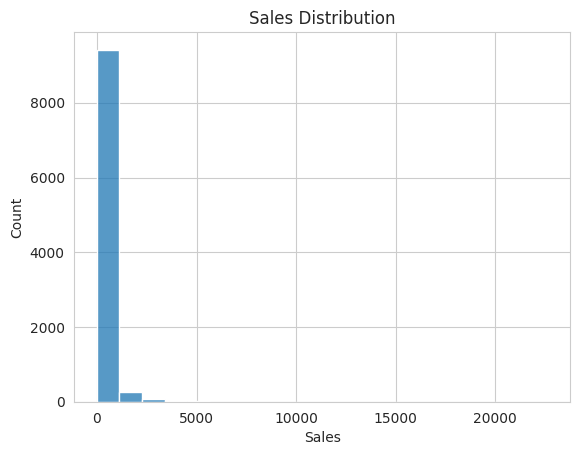

In [25]:
sns.histplot(df['Sales'], bins=20)
plt.title("Sales Distribution")
plt.show()

### 📊 Sales Distribution - Insight
The distribution of sales indicates that most transactions are of lower value, while a small number of high-value transactions contribute significantly to total revenue. This highlights a skewed distribution.

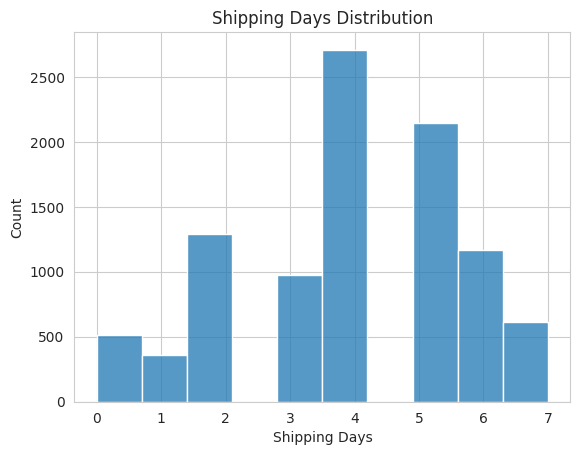

In [ ]:
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

sns.histplot(df['Shipping Days'], bins=10)
plt.title("Shipping Days Distribution")
plt.show()

### 🚚 Shipping Days Analysis - Insight
Most deliveries are completed within 3–5 days, indicating a standard delivery window. However, there are delays observed in the 5–6 day range, along with a few same-day deliveries, which may represent express shipping or data inconsistencies.

In [20]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

### 💡 Overall Business Insights
- Revenue is heavily driven by the West region and Consumer segment
- Technology products dominate sales performance
- Sales exhibit strong seasonality during the year-end period
- Delivery inefficiencies exist, particularly in delayed shipments beyond 5 days
- Sales are concentrated in a limited number of sub-categories

### 🚀 Business Recommendations
- Optimize logistics to reduce delivery delays beyond 5 days
- Focus marketing efforts on high-performing segments such as Consumer
- Increase inventory and promotion of Technology products
- Plan strategic campaigns during peak sales periods (Sep–Dec)
- Diversify product offerings to reduce dependency on a few sub-categories